In [102]:
%matplotlib inline
import cv2
import os
import numpy as np
from skimage.morphology import skeletonize
from scipy import ndimage
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from pathlib import Path
import utils

In [ ]:
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee.jpg'
edges_rough_image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee-edges.jpg'

if not os.path.exists(image_path):
    print(f"Image path does not exist: {image_path}")
if not os.path.exists(edges_rough_image_path):
    print(f"Edges rough image path does not exist: {edges_rough_image_path}")

color_img = cv2.imread(image_path)
mask_img = cv2.imread(edges_rough_image_path, cv2.IMREAD_GRAYSCALE)

# kernel_size = 5
# mask_img = cv2.dilate(mask_img, np.ones((kernel_size, kernel_size), np.uint8), iterations=1)

In [104]:
# Basic skeletonization
# Thresholding
_, binary_img = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)

# 1. Scikit-image's skeletonize expects a boolean image (True where white, False where black)
# We convert the 0-255 image to boolean.
bool_img = binary_img > 0

# 2. Apply Skeletonization
# This is the core step that thins the lines to 1 pixel
skeleton_basic = skeletonize(bool_img)
skeleton_basic = (skeleton_basic * 255).astype(np.uint8)

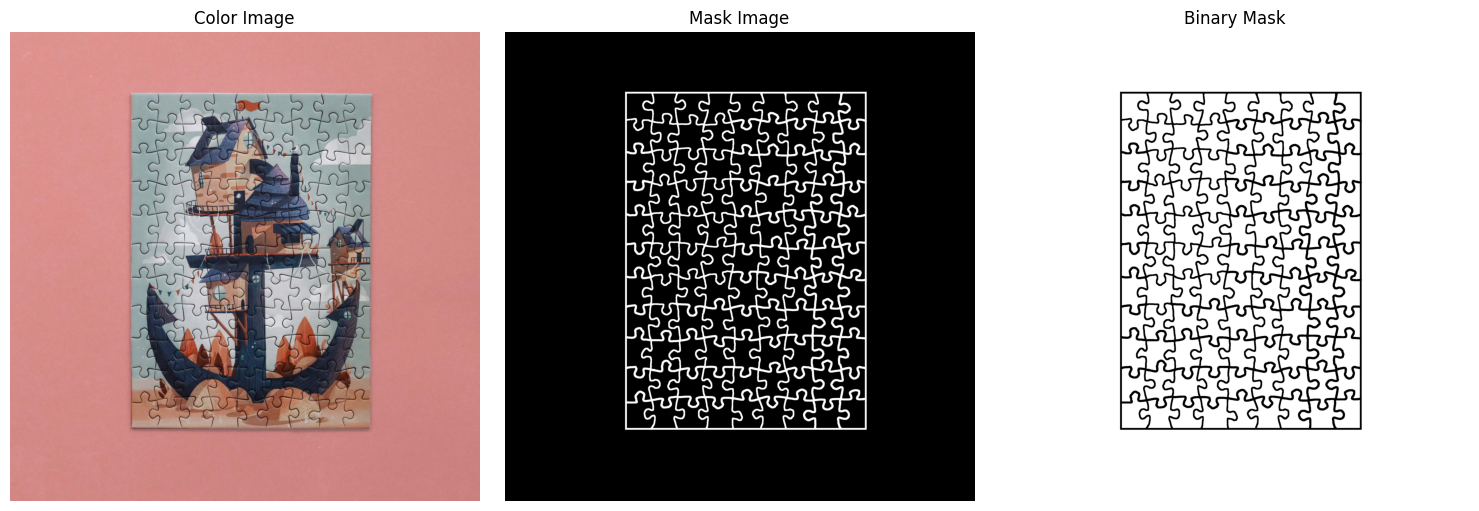

In [105]:
utils.show_images_row([color_img, mask_img, binary_img], titles=["Color Image", "Mask Image", "Binary Mask"])

In [ ]:
gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
_, binary_mask = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)
binary_mask_norm = binary_mask.astype(np.uint8) // 255  # Normalize to 0 and 1

# 2. Distance Transform of the mask
# This identifies the geometric center of your 5px lines
dist_transform = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
cv2.normalize(dist_transform, dist_transform, 0, 1.0, cv2.NORM_MINMAX)

# 3. Process Intensity
# We invert grayscale so dark edges have HIGH values (ridges)
inv_gray = 255 - gray
inv_gray_float = inv_gray.astype(float)
cv2.normalize(inv_gray_float, inv_gray_float, 0, 1.0, cv2.NORM_MINMAX)

# 4. Create the Potential Map (The Fusion)
# We multiply them so a pixel must be in the mask AND be dark to stay bright
# You can weight them: 0.7 * dist + 0.3 * intensity
# potential_map = dist_transform * inv_gray_float
potential_map = dist_transform * inv_gray_float
# potential_map = binary_mask_norm * inv_gray_float

# 5. Extract the 1-pixel Skeleton
# We threshold the potential map to get the "strongest" ridge candidates
# Then skeletonize to ensure it's exactly 1px wide
ridge_candidates = potential_map > (potential_map.max() * 0.1) # Adjust threshold as needed
final_skeleton = skeletonize(ridge_candidates)

# Result
skeleton_output = (final_skeleton * 255).astype(np.uint8)


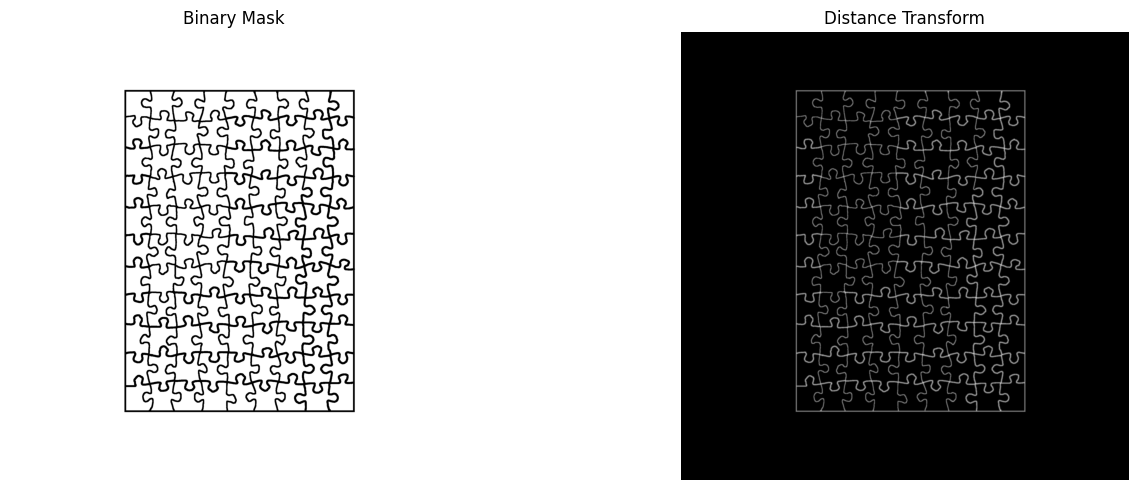

In [107]:
utils.show_images_row([binary_mask, dist_transform], titles=["Binary Mask", "Distance Transform"])

In [108]:
print('Percentage of difference : ' + str(sum(sum(skeleton_output != skeleton_basic)) / skeleton_basic.size * 100)) 
np.unique(skeleton_output)
cv2.imwrite('Mask image.png', mask_img)
cv2.imwrite('dist_transform.png', img_as_ubyte(dist_transform))
cv2.imwrite('skeleton_basic_output.png', skeleton_basic)
cv2.imwrite('skeleton_potential_output.png', skeleton_output)
cv2.imwrite('potential_map.png', img_as_ubyte(potential_map))

Percentage of difference : 0.049713134765625


True

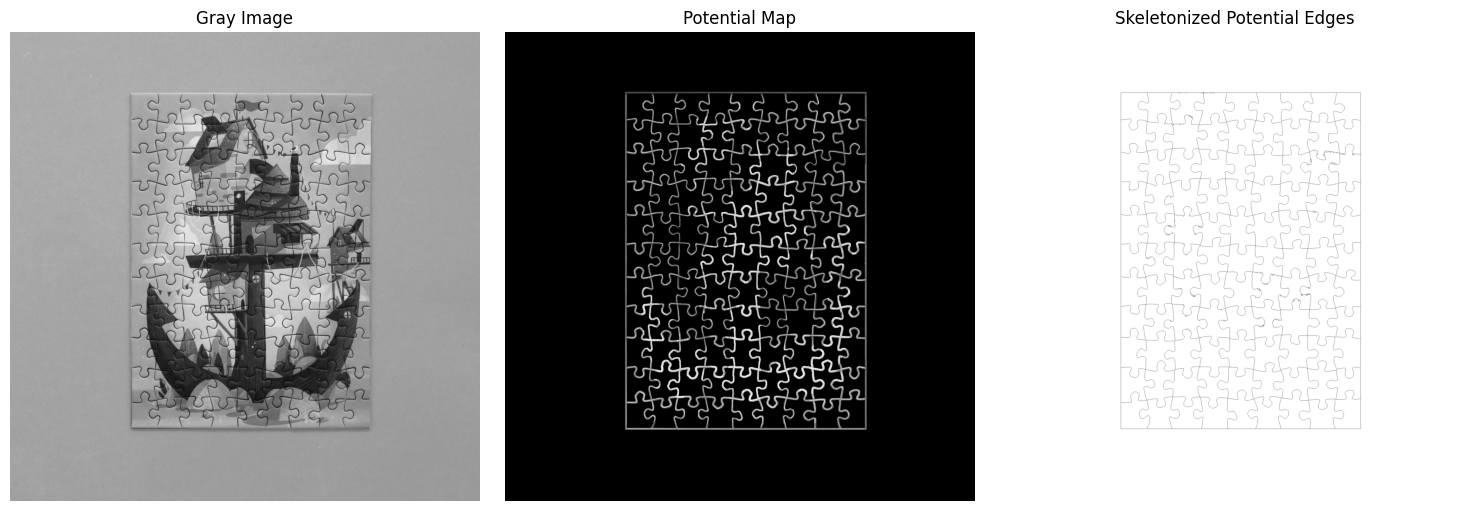

In [109]:
utils.show_images_row([gray, potential_map, skeleton_output], titles=["Gray Image", "Potential Map", "Skeletonized Potential Edges"])
